# Diseño y cuantización de un IIR - DC Blocker

In [50]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [51]:
# Detectar raíz del proyecto de forma relativamente robusta
CURRENT_DIR = Path.cwd()

# Si el notebook corre desde TP1_FIR_IIR/fir, la raíz está dos niveles arriba
PROJECT_ROOT = CURRENT_DIR.parents[1]

UTILS_DIR = PROJECT_ROOT / "utils"

if str(UTILS_DIR) not in sys.path:
    sys.path.append(str(UTILS_DIR))

print(f"Current dir : {CURRENT_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Utils dir   : {UTILS_DIR}")

Current dir : c:\Users\damik\OneDrive\Documentos\GitHub\VLSI_2026\TP1_FIR_IIR\iir
Project root: c:\Users\damik\OneDrive\Documentos\GitHub\VLSI_2026
Utils dir   : c:\Users\damik\OneDrive\Documentos\GitHub\VLSI_2026\utils


In [52]:
from fixed_point import FixedPointFormat, FixedPoint

## IIR - DC Blocker

Se desea eliminar una componente DC no deseada de una señal proveniente de un ADC signed de 8 bits.

Se utiliza el filtro:

$$
H(z)=\frac{z-1}{z-a}
$$

La ecuación en diferencias es:

$$
y[n] = x[n] - x[n-1] + a y[n-1]
$$

Donde:

- $a$ controla qué tan cerca de DC está la frecuencia de corte.
- Para estabilidad se requiere $(|a| < 1)$.

### Modelo en punto flotante

In [53]:
def dc_blocker(x, a):
    """
    Implementa:
        y[n] = x[n] - x[n-1] + a*y[n-1]

    Modelo en punto flotante.
    """
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)

    x_prev = 0.0
    y_prev = 0.0

    for n in range(len(x)):
        y[n] = x[n] - x_prev + a * y_prev

        x_prev = x[n]
        y_prev = y[n]

    return y

### Señal de prueba con offset de DC

In [54]:
FS = 1000
N  = 1000

t = np.arange(N) / FS

f1 = 20.0
f2 = 80.0

x_ac = 0.4*np.sin(2*np.pi*f1*t) + 0.2*np.sin(2*np.pi*f2*t)
dc_offset = 0.2

x_t = x_ac + dc_offset

# Cuantización por ADC signed de 8 bits

ADC_BITS = 8
ADC_FBITS = 7

fmt_x = FixedPointFormat(NB=ADC_BITS, NBF=ADC_FBITS)
fmt_x.info()

x_t_q, x_t_int = fmt_x.quantize(x_t, rounding="trunc", overflow="saturate")


Formato: Q(8, 7) signed
Bits enteros incluyendo signo: 1
Bits fraccionales           : 7
Resolución                  : 0.0078125
Rango entero                : [-128, 127]
Rango real                  : [-1.0, 0.9921875]


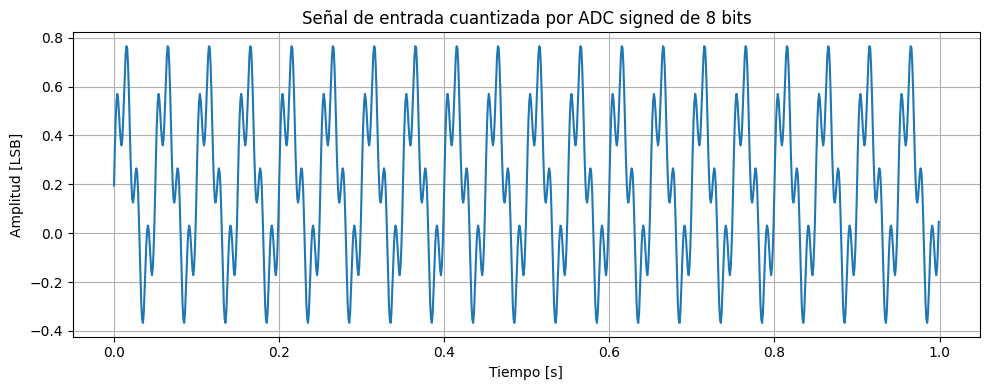

Media de entrada: 0.20
Mínimo: -0.37
Máximo: 0.77


In [55]:
# Plot
plt.figure(figsize=(10, 4))
plt.plot(t, x_t_q)
plt.title("Señal de entrada cuantizada por ADC signed de 8 bits")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [LSB]")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Media de entrada:", f"{np.mean(x_t):.2f}")
print("Mínimo:", f"{np.min(x_t):.2f}")
print("Máximo:", f"{np.max(x_t):.2f}")

### Elección del coeficiente a

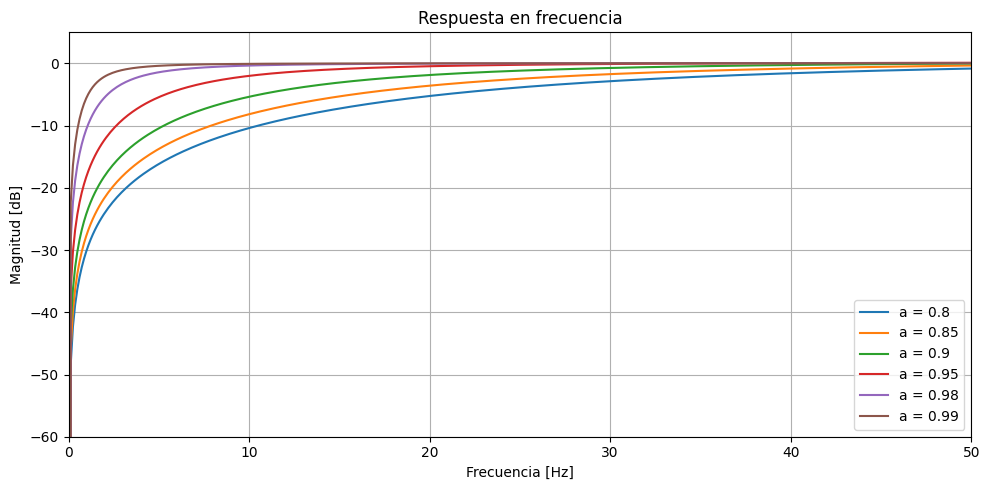

In [56]:
A_VALUES = [0.8, 0.85, 0.90, 0.95, 0.98, 0.99]

def dc_blocker_coefficients(a):
    """
    H(z) = (1 - z^-1) / (1 - a z^-1)
    """
    num = np.array([1.0, -1.0])
    den = np.array([1.0, -a])
    return num, den


plt.figure(figsize=(10, 5))

for a in A_VALUES:
    num, den = dc_blocker_coefficients(a)
    w, h = signal.freqz(num, den, worN=4096, fs=FS)

    h_db = 20*np.log10(np.abs(h) + 1e-12)
    plt.plot(w, h_db, label=f"a = {a}")

plt.title("Respuesta en frecuencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.xlim(0, 50)
plt.ylim(-60, 5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


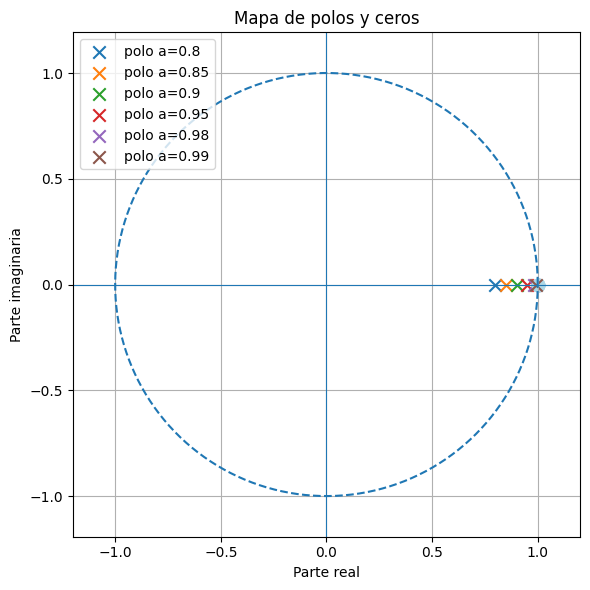

In [57]:
plt.figure(figsize=(6, 6))

# Círculo unitario
theta = np.linspace(0, 2*np.pi, 512)
plt.plot(np.cos(theta), np.sin(theta), "--")

for a in A_VALUES:
    num, den = dc_blocker_coefficients(a)

    zeros = np.roots(num)
    poles = np.roots(den)

    plt.scatter(np.real(zeros), np.imag(zeros), marker="o", facecolors="lightblue", s=80)
    plt.scatter(np.real(poles), np.imag(poles), marker="x", s=80, label=f"polo a={a}")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Mapa de polos y ceros")
plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.grid(True)
plt.axis("equal")
plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

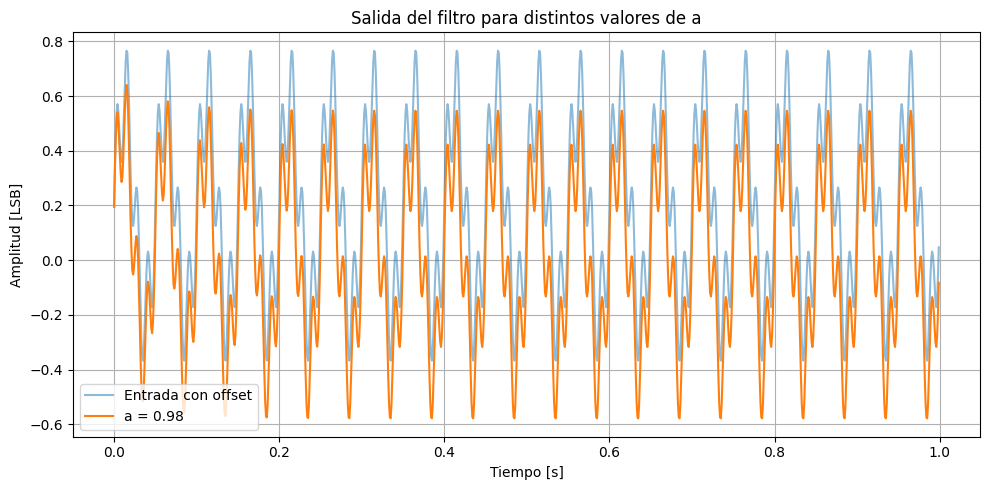

In [58]:
plt.figure(figsize=(10, 5))

plt.plot(t, x_t_q, label="Entrada con offset", alpha=0.5)

a = 0.98

y_t_float = dc_blocker(x_t_q, a)
plt.plot(t, y_t_float, label=f"a = {a}")

plt.title("Salida del filtro para distintos valores de a")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [LSB]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
fmt_a = FixedPointFormat(NB=8, NBF=7)     # Cuantización coeficiente a
fmt_a.info()

a_float = 0.98

a_fx = FixedPoint(a_float, fmt_a, rounding="trunc", overflow="saturate")

print("a float      :", a_float)
print("a fixed      :", a_fx.real_value)
print("a int        :", a_fx.int_value)
print("a hex        :", a_fx.to_hex())
print()
print("Error de cuantización:", f"{(a_float - a_fx.real_value):.6f}")

Formato: Q(8, 7) signed
Bits enteros incluyendo signo: 1
Bits fraccionales           : 7
Resolución                  : 0.0078125
Rango entero                : [-128, 127]
Rango real                  : [-1.0, 0.9921875]
a float      : 0.98
a fixed      : 0.9765625
a int        : 125
a hex        : 7D

Error de cuantización: 0.003437


### Modelado del filtro en FXP

In [72]:
def dc_blocker_fxp(x, a_float, fmt_x, fmt_a, fmt_y):
    """
    Modelo fixed-point del DC blocker equivalente al RTL.

    Implementa:
        y[n] = x[n] - x[n-1] + a*y[n-1]
    """

    y_out = np.zeros(len(x), dtype=float)
    y_int = np.zeros(len(x), dtype=int)

    # Coeficiente como en RTL
    a_fx = FixedPoint(a_float, fmt_a, rounding="trunc", overflow="saturate")

    # Formato intermedio S(16,14)
    NB_FB  = fmt_x.NB + fmt_a.NB
    NBF_FB = fmt_x.NBF + fmt_a.NBF
    fmt_fb = FixedPointFormat(NB=NB_FB, NBF=NBF_FB)

    # Formato de suma S(17,14)
    fmt_sum = FixedPointFormat(NB=NB_FB + 1, NBF=NBF_FB)

    x_prev = FixedPoint(0, fmt_x, from_int=True)
    y_prev = FixedPoint(0, fmt_y, from_int=True)

    for n in range(len(x)):
        x_n = FixedPoint(int(x[n]), fmt_x, from_int=True)

        # diff = x[n] - x[n-1]
        diff = x_n - x_prev

        # diff_ext : S(9,7) -> S(16,14)
        diff_ext = diff.resize(fmt_fb, rounding="trunc", overflow="saturate")

        # feedback = a * y[n-1]
        # S(8,7) * S(8,7) -> S(16,14)
        feedback = a_fx * y_prev

        # Por seguridad, resize explícito a S(16,14)
        feedback = feedback.resize(fmt_fb, rounding="trunc", overflow="saturate")

        # y_sum = diff_ext + feedback
        y_sum = diff_ext + feedback

        # Llevar explícitamente a S(17,14)
        y_sum = y_sum.resize(fmt_sum, rounding="trunc", overflow="saturate")

        # S(17,14) -> S(8,7)
        y_next = y_sum.resize(fmt_y, rounding="round", overflow="saturate")

        x_prev = x_n
        y_prev = y_next

        y_out[n] = y_next.real_value
        y_int[n] = y_next.int_value

    return y_out, y_int

In [73]:
fmt_x = FixedPointFormat(NB=8, NBF=7)
fmt_a = FixedPointFormat(NB=8, NBF=7)
fmt_y = FixedPointFormat(NB=8, NBF=7)

a_float = 0.98

y_t_q, y_t_int= dc_blocker_fxp(
    x_t_int,
    a_float,
    fmt_x,
    fmt_a,
    fmt_y
)


### Filtrado con DC Blocker en FXP

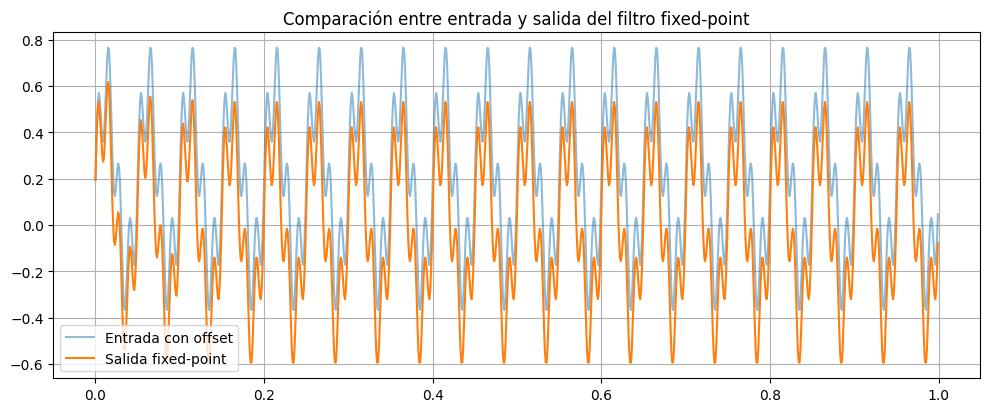

In [74]:
plt.figure(figsize=(10, 4))
plt.plot(t, x_t_q, label="Entrada con offset", alpha=0.5)
plt.plot(t, y_t_q, label="Salida fixed-point")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.title("Comparación entre entrada y salida del filtro fixed-point")
plt.show()

### Comparación float vs FXP

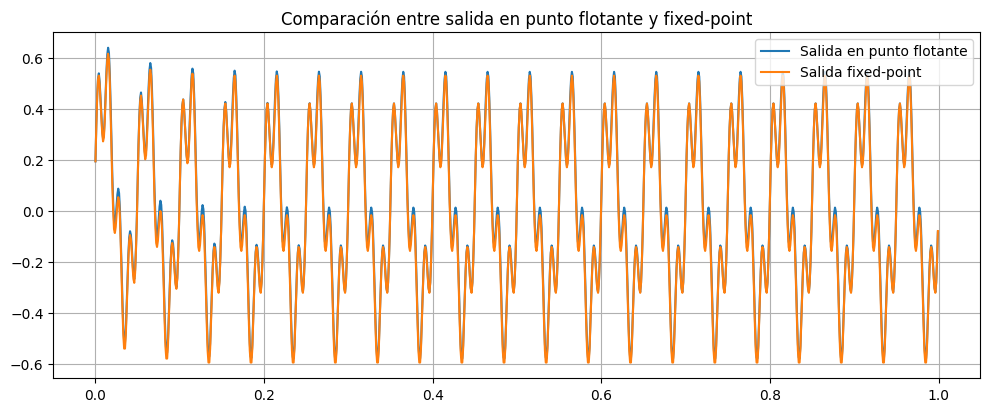

In [75]:
plt.figure(figsize=(10, 4))
plt.plot(t, y_t_float, label="Salida en punto flotante", alpha=1)
plt.plot(t, y_t_q, label="Salida fixed-point")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.title("Comparación entre salida en punto flotante y fixed-point")
plt.show()

In [76]:
print(np.max(x_t_q))
print(np.min(x_t_q))

print(np.max(y_t_q))
print(np.min(y_t_q))

print(np.mean(y_t_q))

0.765625
-0.3671875
0.6171875
-0.59375
-0.008265625


In [77]:
# Carpeta de exportación
EXPORT_DIR = Path("exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
DO_EXPORT = True

def export_hex(path, values, fmt):
    """
    Exporta enteros signed como hexadecimal en complemento a dos.
    """
    values_hex = fmt.to_hex(values)

    with open(path, "w") as f:
        for value in values_hex:
            f.write(f"{value}\n")

if DO_EXPORT:
    export_hex(EXPORT_DIR / "x_t.hex", x_t_int, fmt_x)
    export_hex(EXPORT_DIR / "y_t.hex", y_t_int, fmt_y)